# Bilby Scalar Tensor - Tutorial

While performing agnostics tests of GR is useful, there are some drawbacks. For example:

- Issues when mapping constraints on agnostic parameters over to theory specific parameters.
       - Uniformly sampling agnostic parameters will in general correspond to non-uniform samples on theory specific parameters. Regions of importance can then be undersampled (see Fig. 9 of https://arxiv.org/abs/2406.03568)

For well motivated theories, such as Einstein-scalar-Gauss-Bonnet (EsGB) and dynamical Chern-Simons (dCS), the phase corrections have been computed for various PN orders. Therefore, we can directly feed these coefficients into the TIGER framework and obtain constraints on the parameters that govern these theories. So far, we have considered the corrections due to EsGB.

The EsGB action is given by:

\begin{equation}
       S = \frac{1}{16\pi} \int \mathrm{d}^4 x \sqrt{-g} \left( R - \frac{1}{2}\nabla_\mu \phi \nabla^\mu \phi + \alpha_\mathrm{GB}\phi \mathcal{R}^2_\mathrm{GB} \right)
\end{equation}

where $\mathcal{R}^2_\mathrm{GB} = R_{\mu\nu\rho\sigma}R^{\mu\nu\rho\sigma} - 4R_{\mu\nu}R^{\mu\nu} + R^2$. In this theory, higher order curvature terms source the scalar field $\phi$ (and vice versa) via the global EsGB coupling constant, $\alpha_\mathrm{GB}$. The only additional parameter in this theory is $\alpha_\mathrm{GB}$, so all PN deviation coefficients will be parameterised in terms of this constant and the intrinsic parameters of the binary. In fact, we have

\begin{equation}
       \delta \Psi = \frac{\alpha_\mathrm{GB}^2}{M^4} \sum_{n=-2}^4 \beta_n^\mathrm{EsGB} v^n
\end{equation}

with complete terms up to 1.5PN, and partial information at 2PN. As an example, the functional form of the $\beta_{-2}^\mathrm{EsGB}$ term is:

\begin{equation}
       \beta_{-2}^\mathrm{EsGB} \sim -  \frac{5\pi}{448} \frac{(m_1^2 s_2 - m_2^2 s_1)^2}{\eta^5 M^4},
\end{equation}

where $\eta = m_1 m_2 / M^2$ is the symmetric mass ratio, and the spin dependent factors $s_i$ are given by

\begin{equation}
       s_i = 2\frac{\sqrt{1-\chi_i^2} - 1 + \chi_i^2}{\chi_i^2}.
\end{equation}

These PN terms can be found in https://arxiv.org/abs/2201.02543 and https://arxiv.org/abs/2406.03568. Note the differnet conventions used.

We will proceed with the analysis as before, but now we only need to sample over $\alpha_\mathrm{GB}$.


Bilby Scalar Tensor can be found at https://git.ligo.org/gwtgr/bilby_scalar_tensor.

In [ ]:
# This is to suppress a SWIG warning when import lal via bilby
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import bilby
import bilby_scalar_tensor

# Some standard imports
import numpy as np
#from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
        'axes.grid': False,
        'axes.labelsize': 12,
        'axes.linewidth': 0.8,
        'axes.titlesize': 12,
        'font.size': 16,
        'legend.fontsize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'font.family': 'serif',
        'font.sans-serif': ['Bitstream Vera Sans'],
        'font.serif': ['Times New Roman'],
        'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{amsfonts}',
        'text.usetex': True,
        'patch.force_edgecolor': True,
        'figure.dpi': 500,
        'savefig.dpi': 1000,
    }
)

In [3]:
?bilby_scalar_tensor.esgb.source.lal_binary_black_hole_esgb

Signature:
bilby_scalar_tensor.esgb.source.lal_binary_black_hole_esgb(
    frequency_array,
    mass_1,
    mass_2,
    luminosity_distance,
    a_1,
    tilt_1,
    phi_12,
    a_2,
    tilt_2,
    phi_jl,
    theta_jn,
    phase,
    alpha_gb_sqrt,
    **kwargs,
)
Docstring:
A binary black hole waveform using lalsimulation with EsGB corrections
added to the waveform phase.

Corrections are added as absolute deviations, i.e phi_n = phi_n_GR + dchi_n.

Parameters
----------
frequency_array: array_like
    The frequencies at which we want to calculate the strain
mass_1: float
    The mass of the heavier object in solar masses
mass_2: float
    The mass of the lighter object in solar masses
luminosity_distance: float
    The luminosity distance in megaparsec
a_1: float
    Dimensionless primary spin magnitude
tilt_1: float
    Primary tilt angle
phi_12: float
    Azimuthal angle between the component spins
a_2: float
    Dimensionless secondary spin magnitude
tilt_2: float
    Secondary 

In [4]:
frequency_array = np.logspace(np.log10(20), np.log10(2000), 20001)

injection_parameters = dict(
    mass_1 = 30,
    mass_2 = 20,
    luminosity_distance = 5e2,
    a_1 = 0.4,
    tilt_1 = 0.0,
    phi_12 = 0.0,
    a_2 = 0.0,
    tilt_2 = 0.0,
    phi_jl = 0.0,
    theta_jn = 0.0,
    phase = 0.0,
    alpha_gb_sqrt = 0.0,
    geocent_time = 1e9,
    ra = 0.,
    dec = 0.,
    psi = 0.,
)

In [5]:
""" Label of run, and output directory for all the data/results."""

outdir = "outdir"
label = "esgb_injection"

""" Set up bilby logger to capture output messages in a .log file in the outdir. """
bilby.core.utils.setup_logger(outdir=outdir, label=label)
logger = bilby.core.utils.logger

In [6]:
duration = 4
sampling_frequency = 2048
geocent_time = 1e9
waveform_arguments = dict(waveform_approximant = 'IMRPhenomXPHM')

In [7]:
waveform_generator = bilby.gw.WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby_scalar_tensor.esgb.source.lal_binary_black_hole_esgb,
    waveform_arguments=waveform_arguments
)

19:32 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=4, sampling_frequency=2048, start_time=0, frequency_domain_source_model=bilby_scalar_tensor.esgb.source.lal_binary_black_hole_esgb, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomXPHM'})


In [8]:
interferometers = bilby.gw.detector.InterferometerList(["H1", "L1"])
for interferometer in interferometers:
    interferometer.minimum_frequency = 20
    interferometer.maximum_frequency = 2000

""" Here we determine the start time by taking the time of peak strain, add some small time buffer for the post-merger signal, and then subtracting the total duration."""
start_time = geocent_time + 0.5 - duration
interferometers.set_strain_data_from_zero_noise(sampling_frequency=sampling_frequency, duration=duration, start_time=start_time)

injection_parameters['geocent_time'] = geocent_time
injection_parameters['ra'] = 0.0
injection_parameters['dec'] = 0.0
injection_parameters['psi'] = 0.0

interferometers.inject_signal(parameters=injection_parameters, waveform_generator=waveform_generator)

print(interferometers.meta_data)

19:32 bilby INFO    : Injected signal in H1:
19:32 bilby INFO    :   optimal SNR = 19.55
19:32 bilby INFO    :   matched filter SNR = 19.55+0.00j
19:32 bilby INFO    :   mass_1 = 30
19:32 bilby INFO    :   mass_2 = 20
19:32 bilby INFO    :   luminosity_distance = 500.0
19:32 bilby INFO    :   a_1 = 0.4
19:32 bilby INFO    :   tilt_1 = 0.0
19:32 bilby INFO    :   phi_12 = 0.0
19:32 bilby INFO    :   a_2 = 0.0
19:32 bilby INFO    :   tilt_2 = 0.0
19:32 bilby INFO    :   phi_jl = 0.0
19:32 bilby INFO    :   theta_jn = 0.0
19:32 bilby INFO    :   phase = 0.0
19:32 bilby INFO    :   alpha_gb_sqrt = 0.0
19:32 bilby INFO    :   geocent_time = 1000000000.0
19:32 bilby INFO    :   ra = 0.0
19:32 bilby INFO    :   dec = 0.0
19:32 bilby INFO    :   psi = 0.0
19:32 bilby INFO    : Injected signal in L1:
19:32 bilby INFO    :   optimal SNR = 25.54
19:32 bilby INFO    :   matched filter SNR = 25.54-0.00j
19:32 bilby INFO    :   mass_1 = 30
19:32 bilby INFO    :   mass_2 = 20
19:32 bilby INFO    :   

{'H1': {'name': 'H1', 'optimal_SNR': 19.55096316591583, 'matched_filter_SNR': (19.55096316591583+7.95163104221746e-18j), 'parameters': {'mass_1': 30, 'mass_2': 20, 'luminosity_distance': 500.0, 'a_1': 0.4, 'tilt_1': 0.0, 'phi_12': 0.0, 'a_2': 0.0, 'tilt_2': 0.0, 'phi_jl': 0.0, 'theta_jn': 0.0, 'phase': 0.0, 'alpha_gb_sqrt': 0.0, 'geocent_time': 1000000000.0, 'ra': 0.0, 'dec': 0.0, 'psi': 0.0}}, 'L1': {'name': 'L1', 'optimal_SNR': 25.538569707044694, 'matched_filter_SNR': (25.53856970704469-6.3582491620257096e-18j), 'parameters': {'mass_1': 30, 'mass_2': 20, 'luminosity_distance': 500.0, 'a_1': 0.4, 'tilt_1': 0.0, 'phi_12': 0.0, 'a_2': 0.0, 'tilt_2': 0.0, 'phi_jl': 0.0, 'theta_jn': 0.0, 'phase': 0.0, 'alpha_gb_sqrt': 0.0, 'geocent_time': 1000000000.0, 'ra': 0.0, 'dec': 0.0, 'psi': 0.0}}}


In [9]:
chirp_mass = ((injection_parameters['mass_1']*injection_parameters['mass_2'])**(3/5))/((injection_parameters['mass_1']+injection_parameters['mass_2'])**(1/5))
mass_ratio = injection_parameters['mass_2']/injection_parameters['mass_1']

print(f"Chirp Mass: {chirp_mass:.2f}")
print(f"Mass Ratio: {mass_ratio}")

prior_dict = dict(chirp_mass = bilby.gw.prior.UniformInComponentsChirpMass(minimum=10, maximum=40, name='chirp_mass'), 
            mass_ratio = bilby.gw.prior.Uniform(minimum=0.5, maximum=1.0, name='mass_ratio', latex_label='$q$', unit=None), 
            a_1 = bilby.gw.prior.Uniform(minimum=0, maximum=0.99, name='a_1', latex_label='$a_1$', unit=None), 
            a_2 = bilby.gw.prior.Uniform(minimum=0, maximum=0.99, name='a_2', latex_label='$a_2$', unit=None), 
            tilt_1 = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='tilt_1'), 
            tilt_2 = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='tilt_2'), 
            phi_12 = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='phi_12', boundary='periodic'), 
            phi_jl = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='phi_jl', boundary='periodic'), 
            luminosity_distance = bilby.gw.prior.PowerLaw(alpha=2, minimum=1e2, maximum=1e4, name='luminosity_distance', latex_label='$d_L$', unit='Mpc'), 
            theta_jn = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='theta_jn'), 
            psi = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='psi', boundary='periodic'), 
            phase = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='phase', boundary='periodic'), 
            dec = bilby.gw.prior.Uniform(minimum=0, maximum=0.1, name='dec'), 
            ra = bilby.gw.prior.Uniform(name='ra', minimum=0, maximum=0.1, boundary='periodic'),
            geocent_time = bilby.gw.prior.Uniform(name='geocent_time', minimum=injection_parameters['geocent_time']-0.1, maximum=injection_parameters['geocent_time']+0.1),
            alpha_gb_sqrt = bilby.gw.prior.Uniform(minimum=0.0, maximum=20.0, name='alpha_gb_sqrt', latex_label='$\sqrt{\alpha_\mathrm{GB}}$', unit = '$km$'))

priors = bilby.gw.prior.BBHPriorDict(prior_dict)

Chirp Mass: 21.24
Mass Ratio: 0.6666666666666666


In [10]:
likelihood = bilby.gw.likelihood.GravitationalWaveTransient(
    interferometers            = interferometers, 
    waveform_generator         = waveform_generator,
    priors                     = priors, 
    distance_marginalization   = True,
    phase_marginalization      = False,
    time_marginalization       = True,
)

19:32 bilby INFO    : Loaded distance marginalisation lookup table from .distance_marginalization_lookup.npz.


In [11]:
nlive   = 200
sampler = 'dynesty'

result  = bilby.run_sampler(
    likelihood          = likelihood, 
    priors              = priors,
    outdir              = outdir, 
    label               = label,
    sampler             = sampler, 
    nlive               = nlive, 
    sample              = 'rslice',
    slices              = 20,
    n_check_point       = 200, 
    check_point_plot    = True,
    conversion_function = bilby.gw.conversion.generate_all_bbh_parameters,
    npool               = 6
)

19:32 bilby INFO    : Running for label 'esgb_injection', output will be saved to 'outdir'
19:32 bilby INFO    : Using lal version 7.7.0.1
19:32 bilby INFO    : Using lal git version Branch: beyond_gr_param;Tag: None;Id: 7408ce88bdc296b0f6eb12ca6d2390cbb2781b2d;;Builder: Shaun Nicholas Swain <sswain@star.sr.bham.ac.uk>;Repository status: UNCLEAN: Modified working tree
19:32 bilby INFO    : Using lalsimulation version 6.2.0.1
19:32 bilby INFO    : Using lalsimulation git version Branch: beyond_gr_param;Tag: None;Id: 7408ce88bdc296b0f6eb12ca6d2390cbb2781b2d;;Builder: Shaun Nicholas Swain <sswain@star.sr.bham.ac.uk>;Repository status: UNCLEAN: Modified working tree
19:32 bilby INFO    : Analysis priors:
19:32 bilby INFO    : chirp_mass=bilby.gw.prior.UniformInComponentsChirpMass(minimum=10, maximum=40, name='chirp_mass', latex_label='$\\mathcal{M}$', unit=None, boundary=None)
19:32 bilby INFO    : mass_ratio=Uniform(minimum=0.5, maximum=1.0, name='mass_ratio', latex_label='$q$', unit=None

4506it [07:15,  7.73it/s, bound:628 nc:133 ncall:4.2e+05 eff:1.1% logz-ratio=481.09+/-0.28 dlogz:0.103>0.1]

19:39 bilby INFO    : Written checkpoint file outdir/esgb_injection_resume.pickle
19:40 bilby INFO    : Starting to close worker pool.
19:40 bilby INFO    : Finished closing worker pool.


4511it [07:48,  9.63it/s, bound:629 nc:  1 ncall:4.2e+05 eff:1.1% logz-ratio=481.13+/-0.29 dlogz:0.0005>0.1]

19:40 bilby INFO    : Rejection sampling nested samples to obtain 1067 posterior samples
19:40 bilby INFO    : Sampling time: 0:07:48.274489
19:40 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
19:40 bilby INFO    : Computing per-detector log likelihoods.


...

19:40 bilby INFO    : Reconstructing marginalised parameters.
19:40 bilby INFO    : Using a pool with size 6 for nsamples=1067


100%|██████████| 1067/1067 [00:03<00:00, 311.66it/s]


19:40 bilby INFO    : Computing SNRs for every sample.
19:40 bilby INFO    : Using a pool with size 6 for nsamples=1067


100%|██████████| 1067/1067 [00:00<00:00, 1251.97it/s]


19:40 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
19:40 bilby INFO    : Summary of results:
nsamples: 1067
ln_noise_evidence: -517.229
ln_evidence: -36.097 +/-  0.330
ln_bayes_factor: 481.132 +/-  0.330



In [12]:
result = bilby.gw.result.CBCResult.from_json(f"{outdir}/{label}_result.json")
result.injection_parameters = injection_parameters
result.plot_waveform_posterior(format="pdf")

19:40 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
19:40 bilby INFO    : Generating waveform figure for H1
19:40 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=4, sampling_frequency=2048, start_time=999999996.5, frequency_domain_source_model=bilby_scalar_tensor.esgb.source.lal_binary_black_hole_esgb, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomXPHM'})
19:40 bilby INFO    : Generating waveform figure for L1
19:40 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=4, sampling_frequency=2048, start_time=999999996.5, frequency_domain_source_model=bilby_scalar_tenso

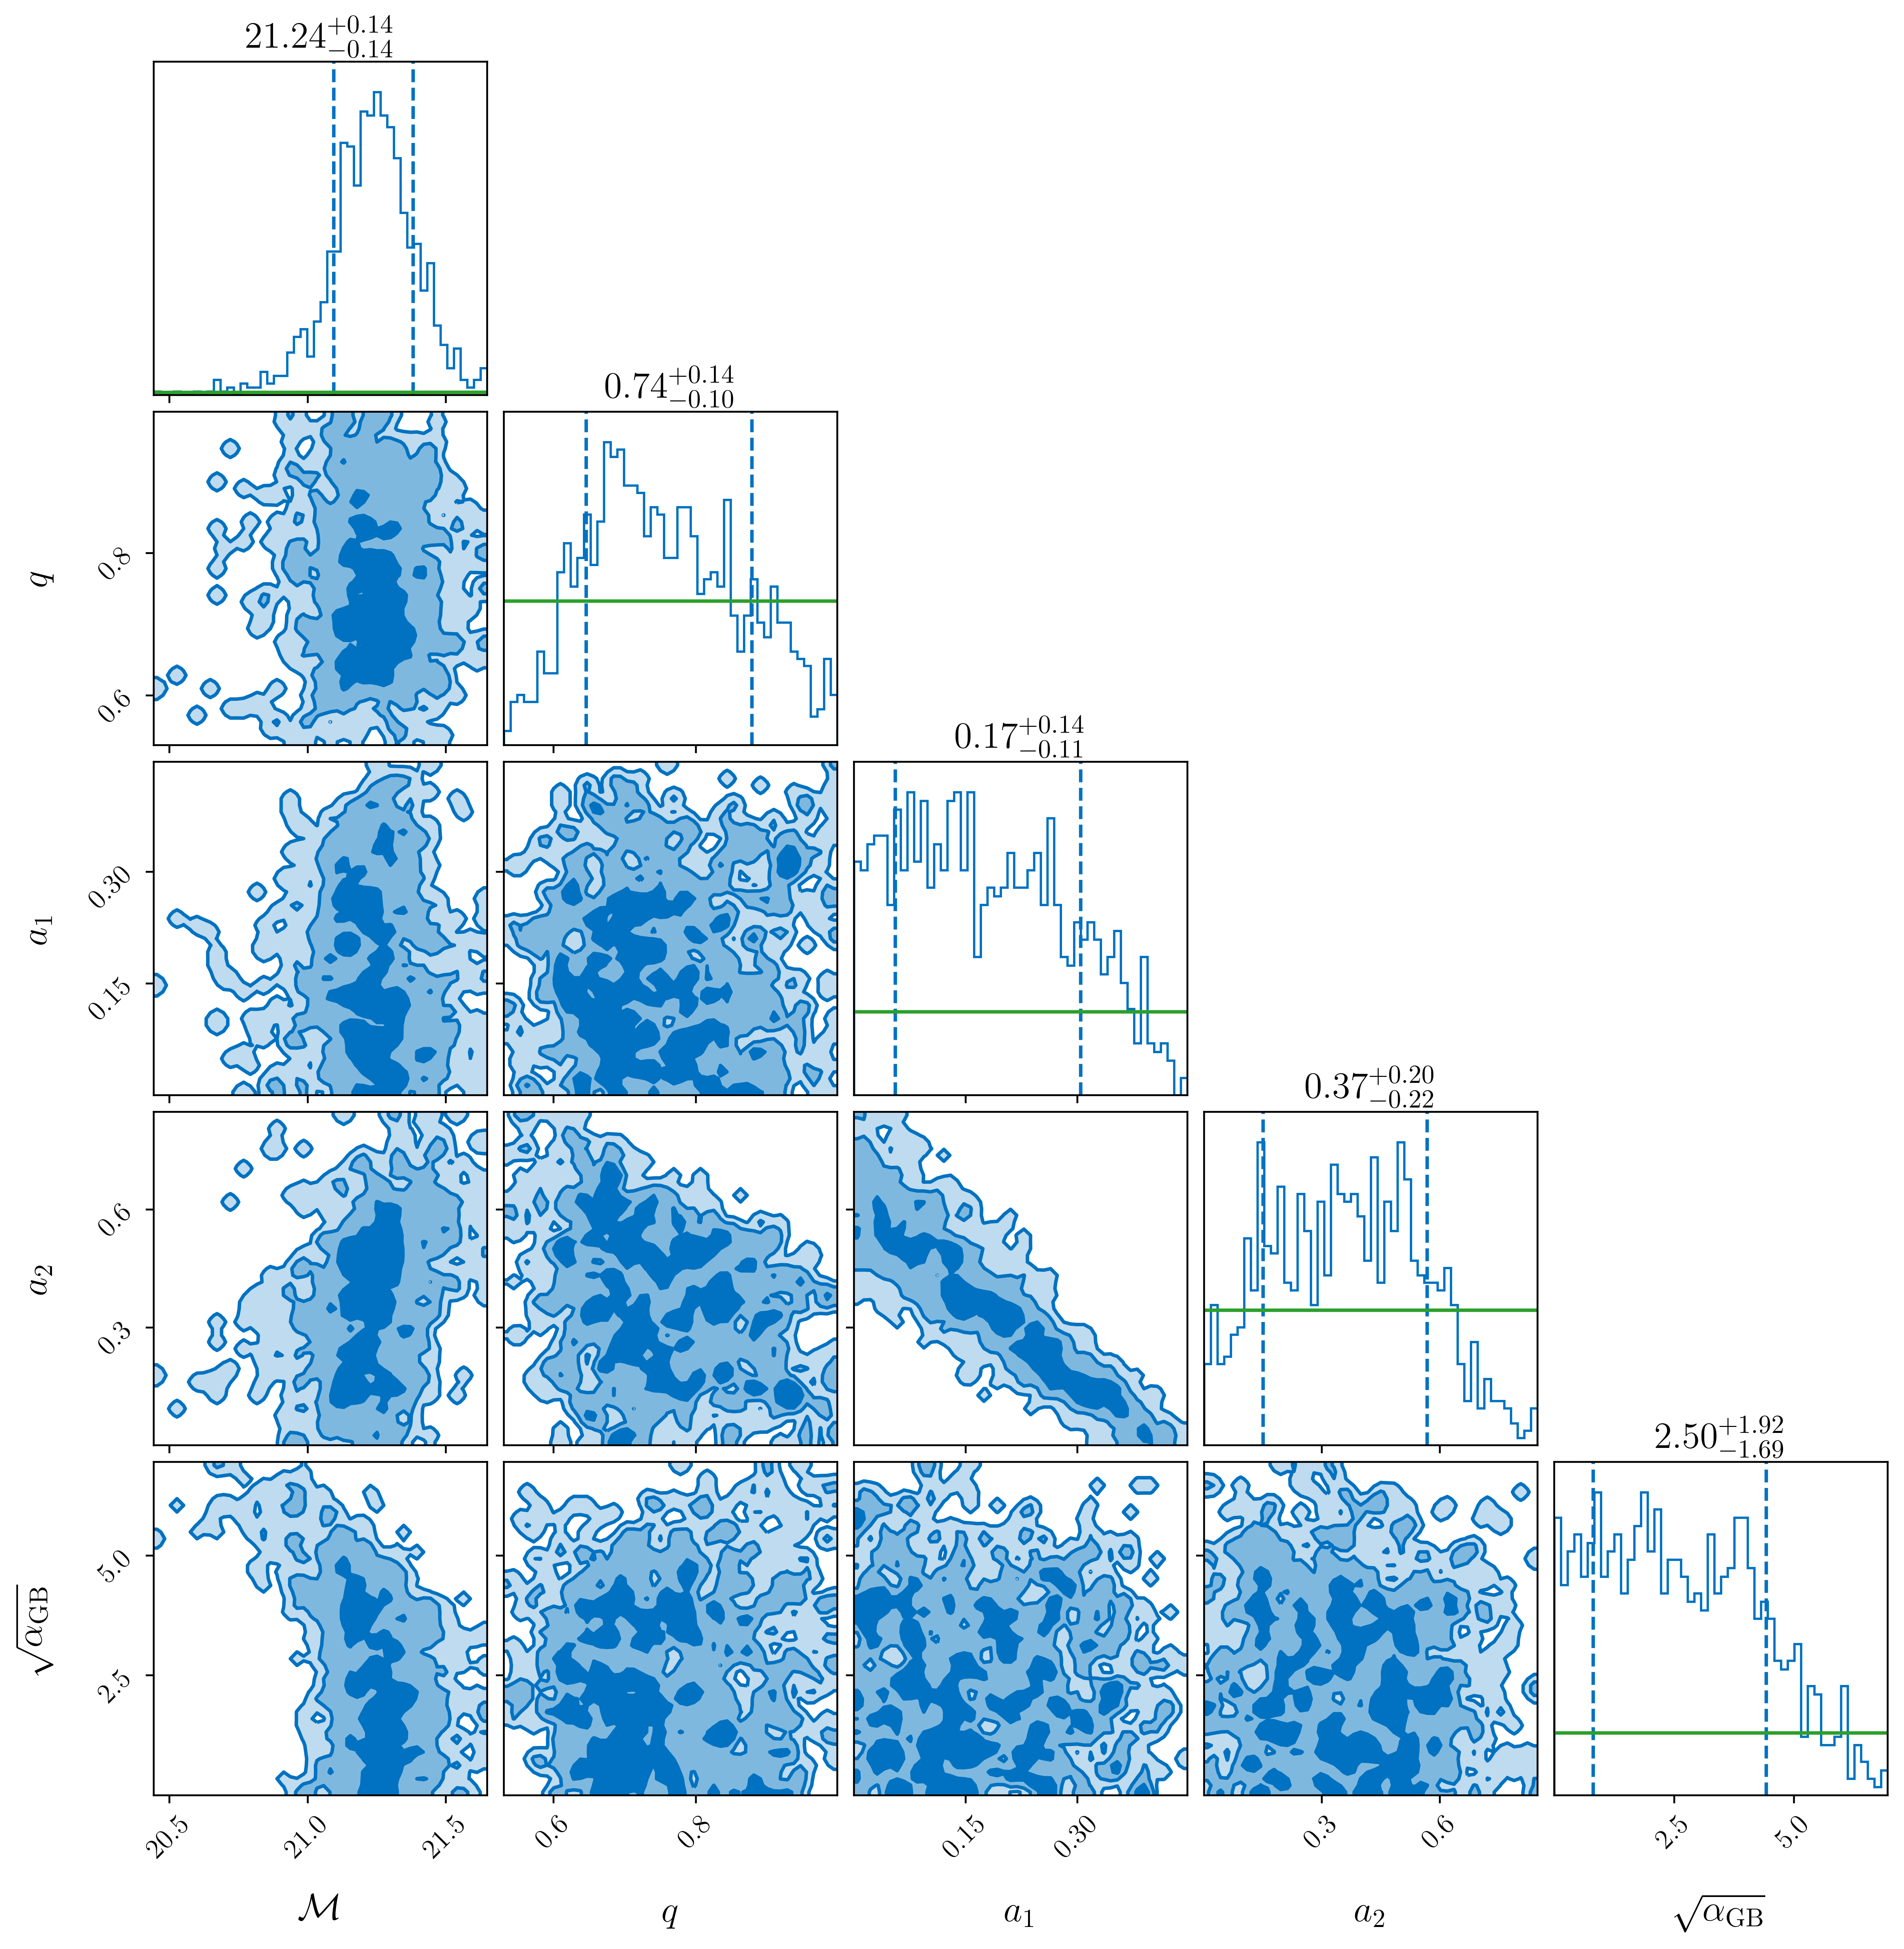

In [13]:
result.plot_corner(
    parameters=["chirp_mass", "mass_ratio", "a_1", "a_2", "alpha_gb_sqrt"],
    priors=True,
    filename=f'{outdir}/{label}_corner_plot.pdf',
    labels=[r'$\mathcal{M}$',r'$q$',r'$a_1$',r'$a_2$',r'$\sqrt{\alpha_\mathrm{GB}}$'],
    dpi=500
    )

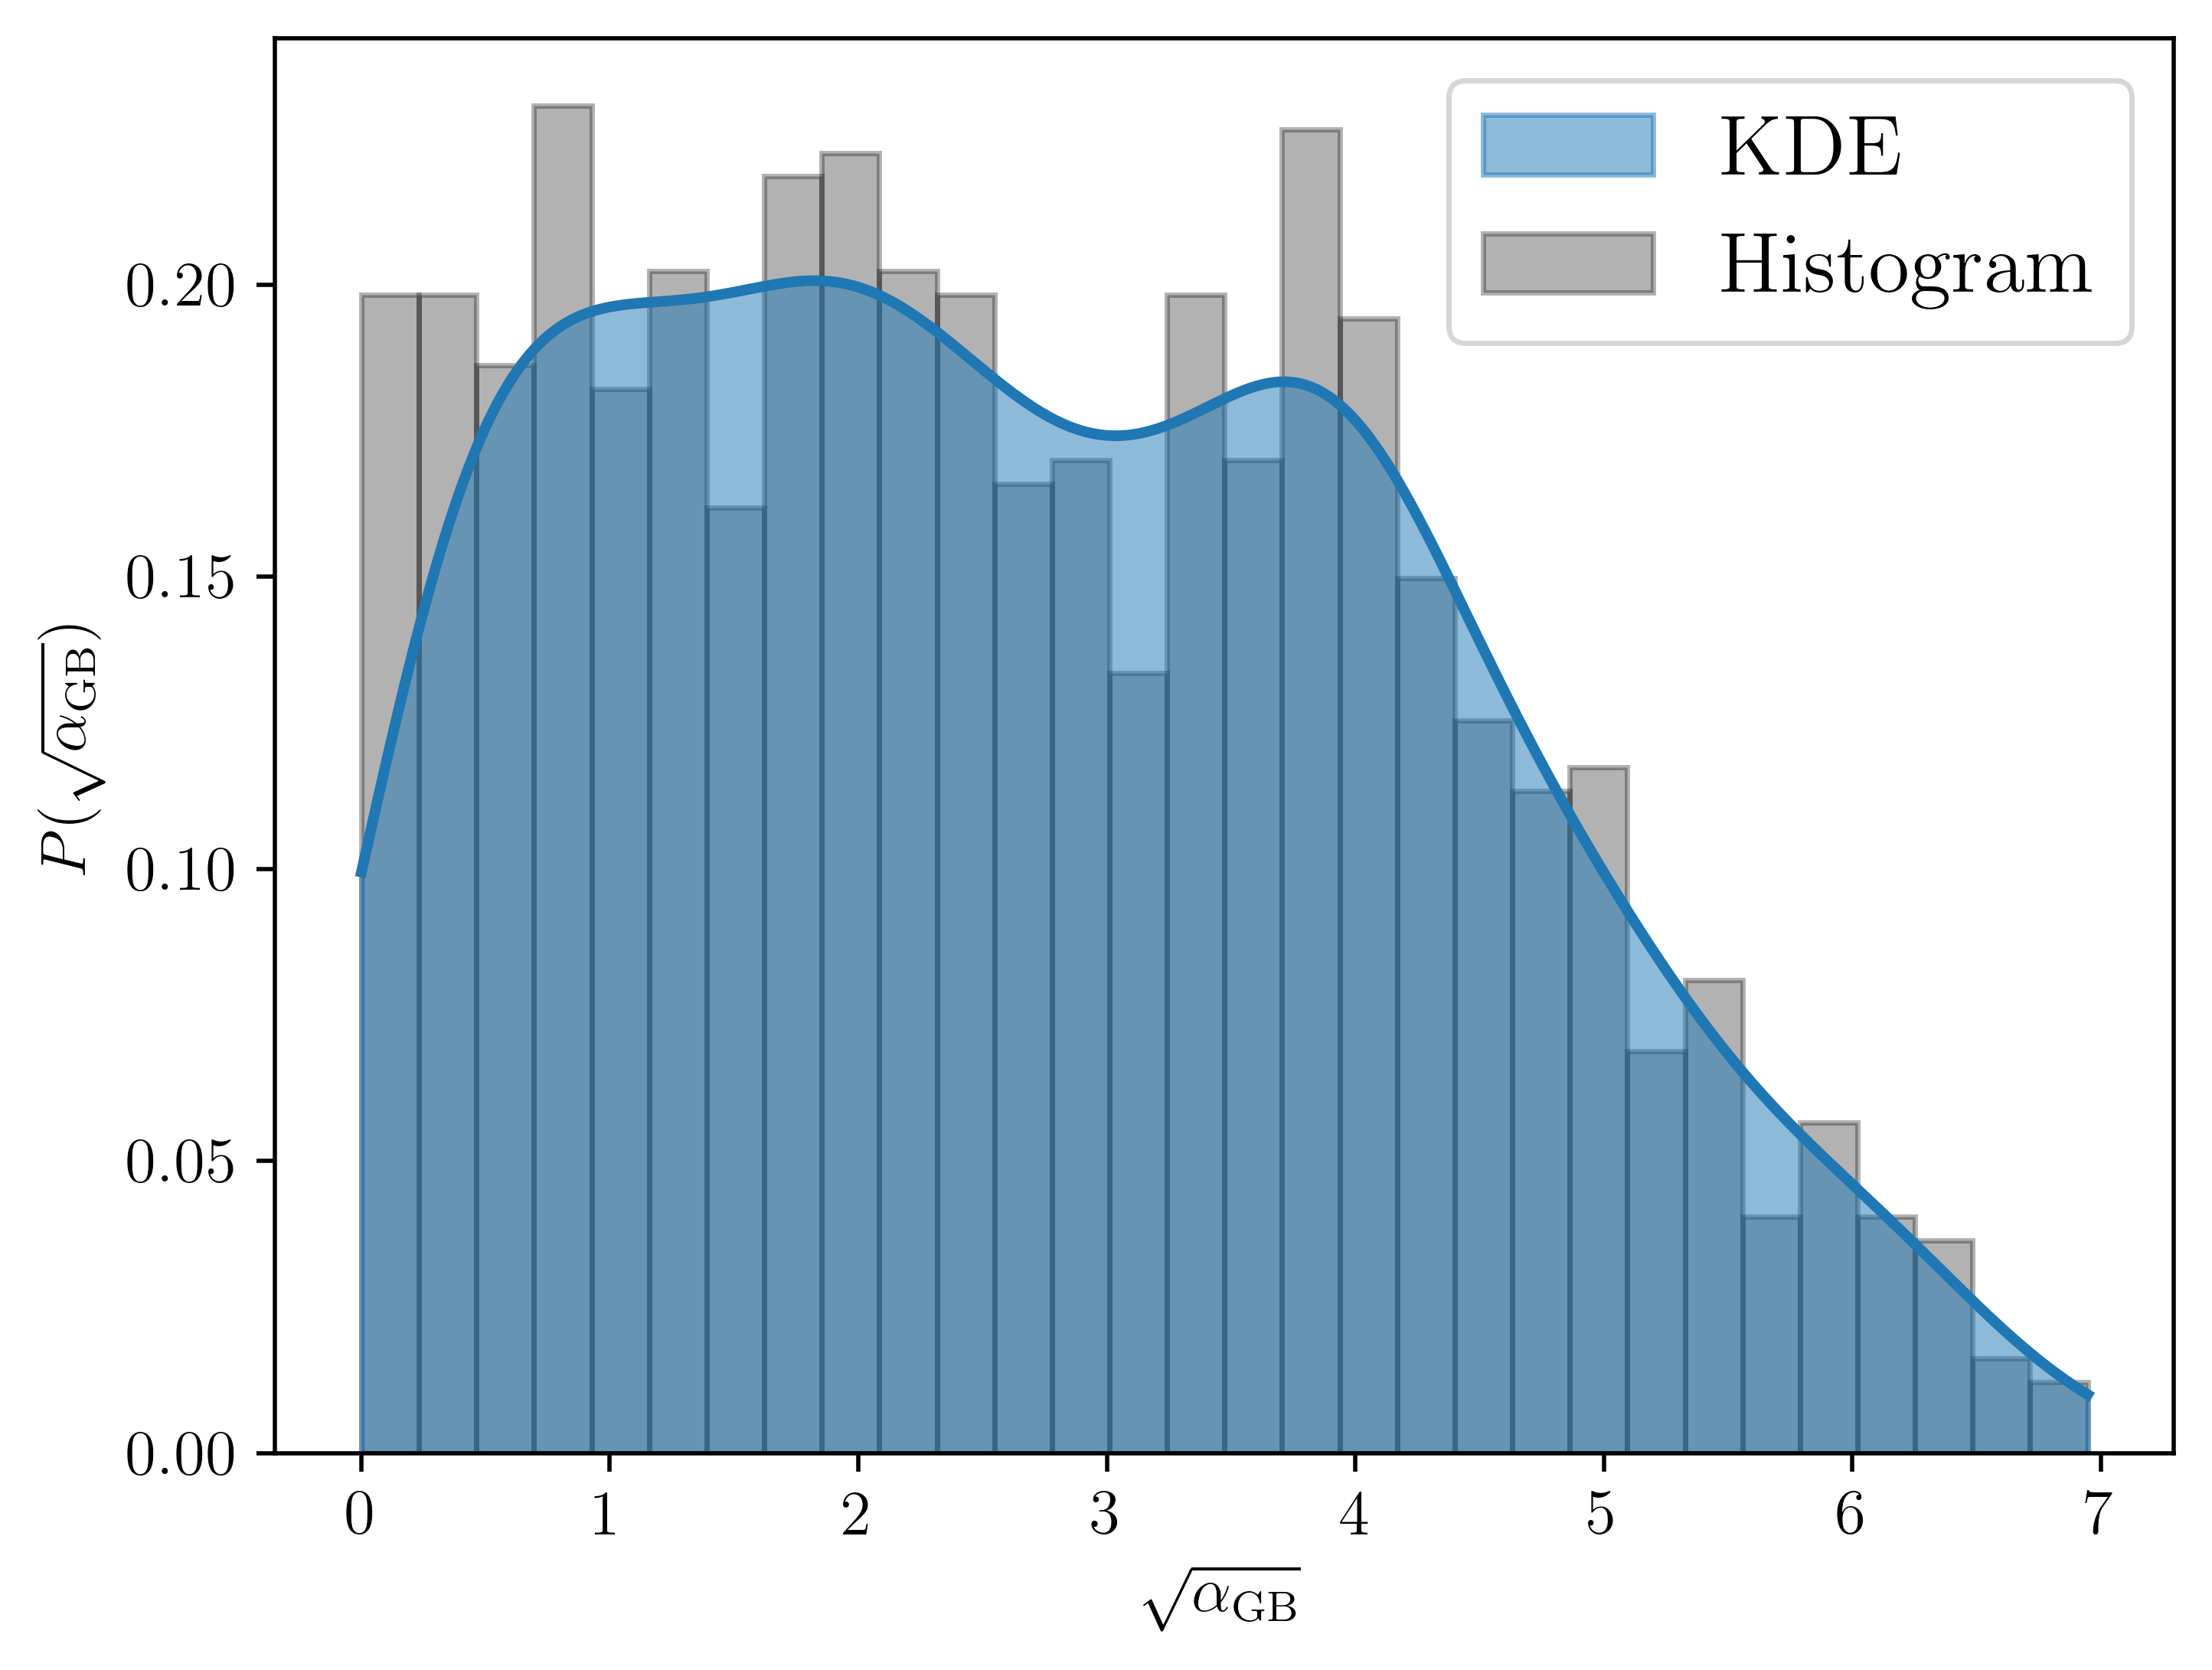

In [14]:
hist = plt.hist(result.posterior["alpha_gb_sqrt"], bins=30, density=True, color='k', alpha=0.3, label='Histogram')
plt.xlabel(r'$\sqrt{\alpha_\mathrm{GB}}$')
plt.ylabel(r'$P(\sqrt{\alpha_\mathrm{GB}})$')

# Overlay KDE as an approximation to the posterior distribution

from scipy.stats import gaussian_kde

samples = result.posterior["alpha_gb_sqrt"]

kde = gaussian_kde(samples)
x_grid = np.linspace(samples.min(), samples.max(), 400)

plt.plot(x_grid, kde(x_grid), color='C0', lw=2)
kde_plot = plt.fill_between(x_grid, kde(x_grid), alpha=0.5, color='C0', label='KDE')

plt.legend(handles=[kde_plot, hist[2][0]])
plt.savefig(f'{outdir}/{label}_1D_marginal_EsGB.pdf')